# T81-558: Applications of Deep Neural Networks
* Instructor: [Jeff Heaton](https://sites.washu.edu/jeffheaton/), McKelvey School of Engineering, [Washington University in St. Louis](https://engineering.washu.edu/index.html)
* For more information visit the [class website](https://sites.washu.edu/jeffheaton/t81-558/).

**Module 5 Assignment: Computer Vision Neural Network**

**Student Name: Your Name**

# Google CoLab Instructions

This assignment will be most straightforward if you use Google CoLab, because it requires both PyTorch and YOLO to be installed. It will be necessary to mount your GDrive so that you can send your notebook during the submit process. Running the following code will map your GDrive to `/content/drive`.

In [1]:
try:
  from google.colab import drive, userdata
  drive.mount('/content/drive', force_remount=True)
  COLAB = True
  print("Note: using Google CoLab")
  key = userdata.get('T81_558_KEY')
except:
  print("Note: not using Google CoLab")
  COLAB = False
  key = None

Mounted at /content/drive
Note: using Google CoLab


# Assignment Submission Library

In [2]:
!pip install https://s3.us-east-1.amazonaws.com/data.heatonresearch.com/library/jh_submit-0.1.0-py3-none-any.whl
import jh_submit

# Assignment Instructions

For this assignment, you will use **YOLO26** (the current Ultralytics release) running on Google CoLab.

You are provided with 10 image files containing webcam pictures taken at the [Venice Sidewalk Cafe](https://www.westland.net/beachcam/), a webcam that has been in operation since 1996.

* https://data.heatonresearch.com/data/t81-558/sidewalk/sidewalk1.jpg
* https://data.heatonresearch.com/data/t81-558/sidewalk/sidewalk2.jpg
* https://data.heatonresearch.com/data/t81-558/sidewalk/sidewalk3.jpg
* https://data.heatonresearch.com/data/t81-558/sidewalk/sidewalk4.jpg
* https://data.heatonresearch.com/data/t81-558/sidewalk/sidewalk5.jpg
* https://data.heatonresearch.com/data/t81-558/sidewalk/sidewalk6.jpg
* https://data.heatonresearch.com/data/t81-558/sidewalk/sidewalk7.jpg
* https://data.heatonresearch.com/data/t81-558/sidewalk/sidewalk8.jpg
* https://data.heatonresearch.com/data/t81-558/sidewalk/sidewalk9.jpg
* https://data.heatonresearch.com/data/t81-558/sidewalk/sidewalk10.jpg

You can see a sample of the webcam here:

![alt text](https://data.heatonresearch.com/data/t81-558/sidewalk/sidewalk1.jpg)

YOLO does quite well at recognizing objects in this webcam, as the following image illustrates.

![alt text](https://data.heatonresearch.com/data/t81-558/sidewalk/predictions.jpg)

Write a script that counts the following object types in each image:

* `person`
* `car`
* `bus`

**Do not include counts for any other classes.**

Your submitted dataframe should contain a column named **image** (integers 1-10) plus one column per object class, for exactly 10 rows total:

| image | bus | car | person |
|-------|-----|-----|--------|
| 1     | 1   | 7   | 18     |
| 2     | 0   | 7   | 23     |
| 3     | 0   | 1   | 13     |
| ...   | ... | ... | ...    |

# Step 1: Install Ultralytics

The `ultralytics` package provides YOLO26 (and all prior YOLO versions) through a single unified API. The cell below upgrades to the latest release.

In [3]:
!pip install -q --upgrade ultralytics
import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 7.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics version: 8.4.165


# Step 2: Load YOLO26

We load the YOLO26 nano variant (`yolo26n.pt`), which will be downloaded automatically on first use. YOLO26 uses the exact same Ultralytics API as prior versions — only the model filename changes.

The `conf=0.1` and `iou=0.8` thresholds are required to match the grader's expected counts. Do not change them.

In [13]:
from ultralytics import YOLO
import pandas as pd

# YOLO26 nano — pretrained on COCO (same 80-class label set as prior versions)
model = YOLO("yolo26n.pt")

# Sanity check on a single image
TEST_IMAGE_FILE = 'https://data.heatonresearch.com/data/t81-558/sidewalk/sidewalk1.jpg'
results = model(TEST_IMAGE_FILE, conf=0.1, iou=0.8, verbose=False)
print(f"Detected {len(results[0].boxes)} objects in test image")

Found https://data.heatonresearch.com/data/t81-558/sidewalk/sidewalk1.jpg locally at sidewalk1.jpg
Detected 25 objects in test image


# Step 3: Results Helper

The helper below converts a YOLO results object into a tidy Pandas DataFrame. It gracefully handles the edge case where no objects are detected in an image.

In [14]:
def results_to_dataframe(results):
    """Convert a YOLO results object to a Pandas DataFrame of detections."""
    lookup = results[0].names
    boxes  = results[0].boxes

    # Return an empty DataFrame if nothing was detected
    if boxes is None or len(boxes) == 0:
        return pd.DataFrame(columns=['class', 'name', 'xmin', 'ymin', 'xmax', 'ymax'])

    data = {
        'class': [int(item) for item in boxes.cls],
        'name':  [lookup[int(item)] for item in boxes.cls],
        'xmin':  [int(box[0]) for box in boxes.xyxy],
        'ymin':  [int(box[1]) for box in boxes.xyxy],
        'xmax':  [int(box[2]) for box in boxes.xyxy],
        'ymax':  [int(box[3]) for box in boxes.xyxy],
    }

    return pd.DataFrame(data)

# Step 4: Process All 10 Images

Found https://data.heatonresearch.com/data/t81-558/sidewalk/sidewalk1.jpg locally at sidewalk1.jpg


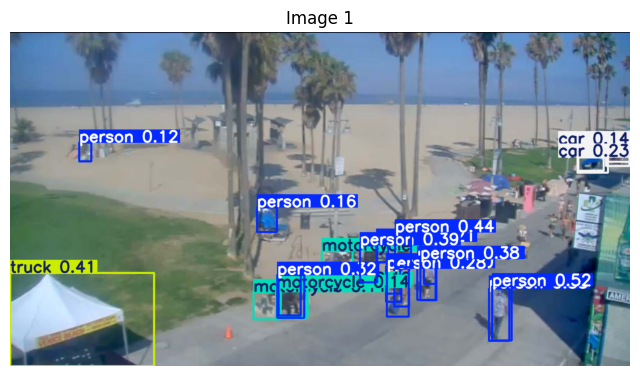

Image  1 | bus= 0  car= 4  person=16
Found https://data.heatonresearch.com/data/t81-558/sidewalk/sidewalk2.jpg locally at sidewalk2.jpg


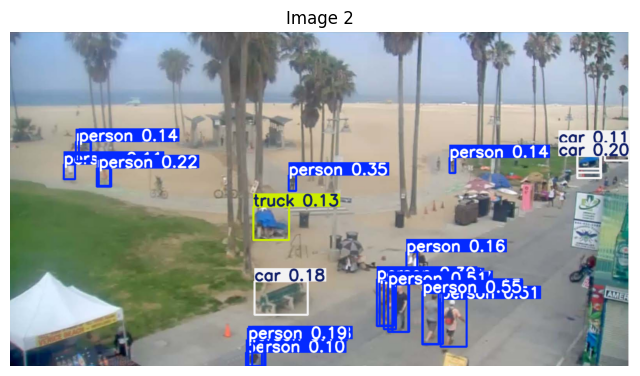

Image  2 | bus= 0  car= 5  person=20
Found https://data.heatonresearch.com/data/t81-558/sidewalk/sidewalk3.jpg locally at sidewalk3.jpg


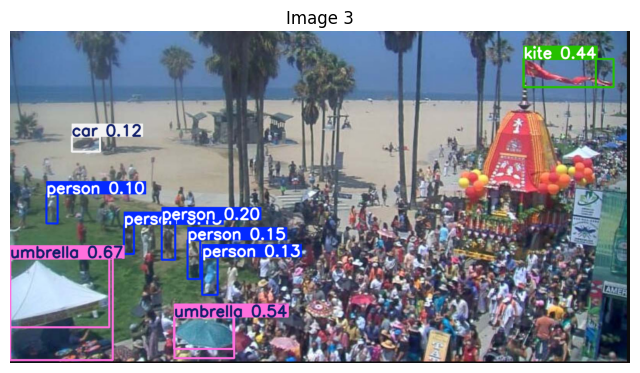

Image  3 | bus= 0  car= 1  person= 5
Found https://data.heatonresearch.com/data/t81-558/sidewalk/sidewalk4.jpg locally at sidewalk4.jpg


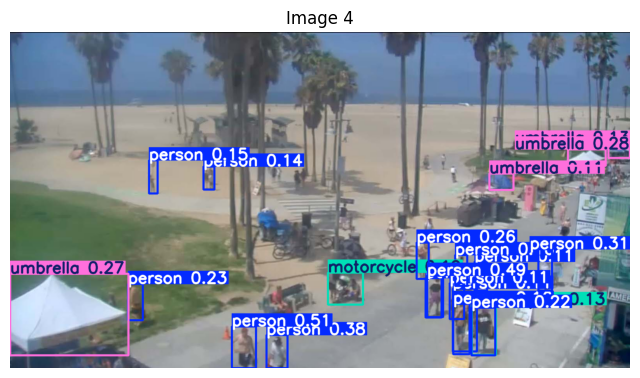

Image  4 | bus= 0  car= 0  person=15
Found https://data.heatonresearch.com/data/t81-558/sidewalk/sidewalk5.jpg locally at sidewalk5.jpg


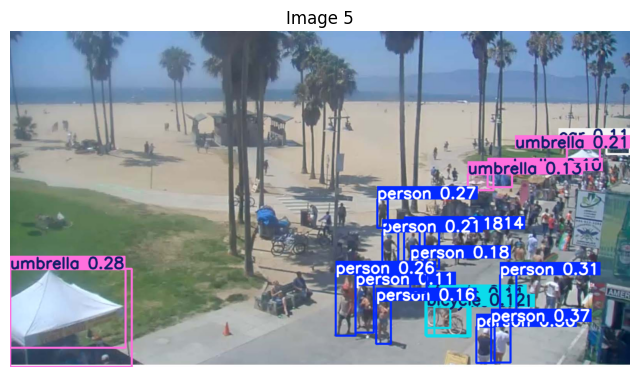

Image  5 | bus= 0  car= 1  person=11
Found https://data.heatonresearch.com/data/t81-558/sidewalk/sidewalk6.jpg locally at sidewalk6.jpg


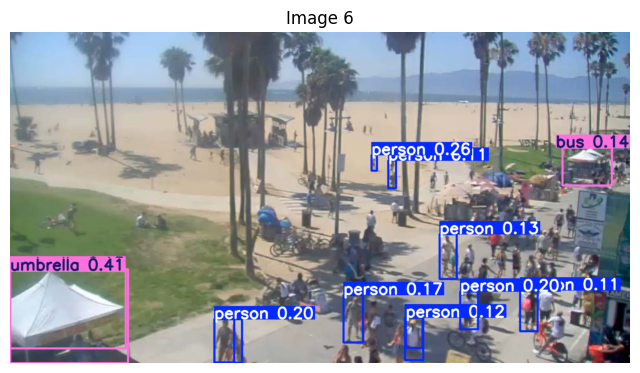

Image  6 | bus= 1  car= 0  person=10
Found https://data.heatonresearch.com/data/t81-558/sidewalk/sidewalk7.jpg locally at sidewalk7.jpg


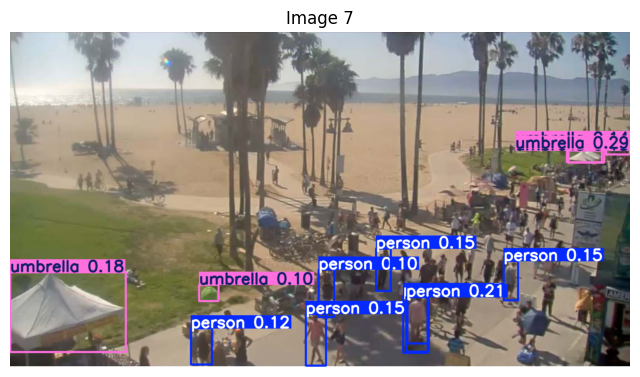

Image  7 | bus= 0  car= 0  person= 8
Found https://data.heatonresearch.com/data/t81-558/sidewalk/sidewalk8.jpg locally at sidewalk8.jpg


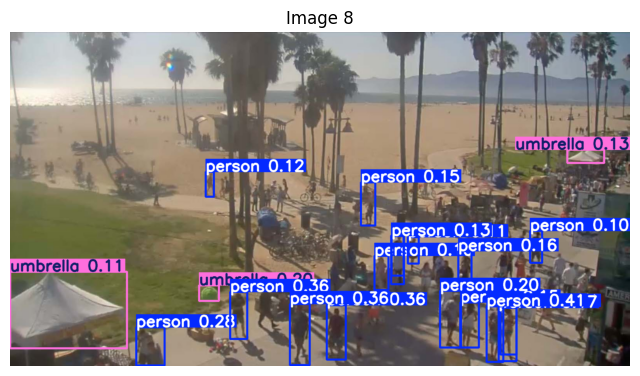

Image  8 | bus= 0  car= 0  person=17
Found https://data.heatonresearch.com/data/t81-558/sidewalk/sidewalk9.jpg locally at sidewalk9.jpg


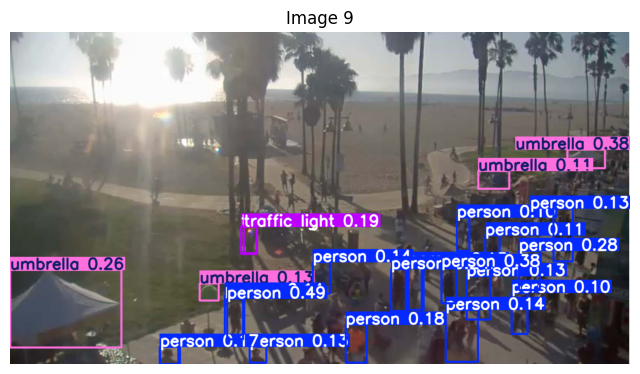

Image  9 | bus= 0  car= 0  person=18
Found https://data.heatonresearch.com/data/t81-558/sidewalk/sidewalk10.jpg locally at sidewalk10.jpg


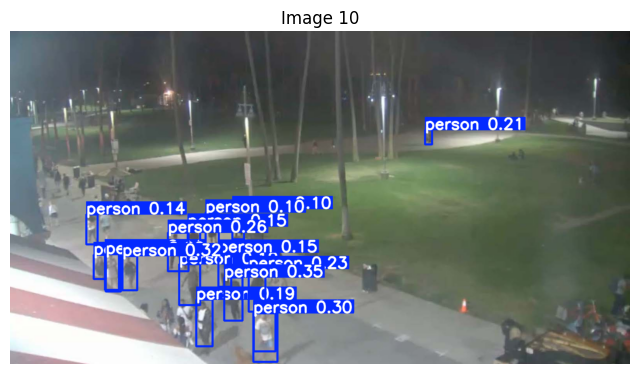

Image 10 | bus= 0  car= 0  person=17

Final submission dataframe:
 image  bus  car  person
     1    0    4      16
     2    0    5      20
     3    0    1       5
     4    0    0      15
     5    0    1      11
     6    1    0      10
     7    0    0       8
     8    0    0      17
     9    0    0      18
    10    0    0      17
     1    0    4      16
     2    0    5      20
     3    0    1       5
     4    0    0      15
     5    0    1      11
     6    1    0      10
     7    0    0       8
     8    0    0      17
     9    0    0      18
    10    0    0      17
     1    0    4      16
     2    0    5      20
     3    0    1       5
     4    0    0      15
     5    0    1      11
     6    1    0      10
     7    0    0       8
     8    0    0      17
     9    0    0      18
    10    0    0      17


In [15]:
import matplotlib.pyplot as plt

for i in range(1, 11):
    url     = BASE_URL.format(i)
    results = model(url, conf=0.1, iou=0.8, verbose=False)

    # Plot detection result
    annotated = results[0].plot()

    plt.figure(figsize=(8, 8))
    plt.imshow(annotated[..., ::-1])  # BGR -> RGB
    plt.axis('off')
    plt.title(f"Image {i}")
    plt.show()

    df_det = results_to_dataframe(results)

    counts = {'image': i}
    for cls in TARGET_CLASSES:
        counts[cls] = int((df_det['name'] == cls).sum())

    print(
        f"Image {i:2d} | "
        f"bus={counts['bus']:2d}  "
        f"car={counts['car']:2d}  "
        f"person={counts['person']:2d}"
    )
    rows.append(counts)

submit_df = pd.DataFrame(
    rows,
    columns=['image', 'bus', 'car', 'person']
)

print("\nFinal submission dataframe:")
print(submit_df.to_string(index=False))

# Step 5: Submit

In [ ]:
# You must identify your source file.  (modify for your local setup)
file="/content/drive/My Drive/Colab Notebooks/assignment_yourname_t81_558_class5.ipynb"  # Google CoLab
# file='C:\\Users\\jeffh\\projects\\t81_558_deep_learning\\assignments\\assignment_yourname_class5.ipynb'  # Windows
# file='/Users/jheaton/projects/t81_558_deep_learning/assignments/assignment_yourname_class5.ipynb'  # Mac/Linux

jh_submit.client.submit(source_file=file, data=[submit_df], key=key, course='t81-558', no=5)